<a href="https://colab.research.google.com/github/olivyaadin/TimeSeriesForecasting/blob/main/Forecasting_LSTM_SVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
!pip install -q scikit-learn tensorflow pandas matplotlib

In [69]:
import os
from google.colab import drive

try:
    drive.mount('/content/drive', force_remount=True, timeout_ms=120000)
except ValueError as e:
    print("Mount gagal. Coba: Runtime > Restart runtime, lalu jalankan ulang sel ini.")
    print("Kalau masih gagal, cek popup/cookie pihak ketiga tidak diblokir di browser.")
    raise e

DRIVE_DATASET_DIR = "/content/drive/MyDrive/business prediction/dataset"

print("Isi folder dataset di Drive:")
!ls -la "{DRIVE_DATASET_DIR}"

Mounted at /content/drive
Isi folder dataset di Drive:
total 19859
-rw------- 1 root root     5027 Jul  8 14:57 dataset_timeseries_stok.csv
-rw------- 1 root root     1661 Jul  7 14:09 fulfilment_center_info.csv
-rw------- 1 root root     1096 Jul  7 14:09 meal_info.csv
-rw------- 1 root root   325744 Jul  7 14:09 sample_submission.csv
-rw------- 1 root root  1266196 Jul  7 14:09 test.csv
-rw------- 1 root root 18733819 Jul  7 14:09 train.csv


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

RAW_DIR = DRIVE_DATASET_DIR
OUT_DIR = "/content/drive/MyDrive/business prediction/processed"
RESULT_DIR = "/content/drive/MyDrive/business prediction/results"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

TRAIN_FILE = os.path.join(RAW_DIR, "train.csv")
MEAL_FILE = os.path.join(RAW_DIR, "meal_info.csv")
CENTER_FILE = os.path.join(RAW_DIR, "fulfilment_center_info.csv")

WINDOW_SIZE = 12                          # dinaikkan dari 8 -> konteks historis lebih kaya
N_CHANNELS = 3                            # [demand, discount_ratio, promo_flag]
TEST_RATIO = 0.2
LSTM_BATCH_SIZE = 16
MIN_WEEKS_PER_CENTER = WINDOW_SIZE + 5    # center dgn histori lebih pendek dari ini dilewati
LSTM_VAL_RATIO = 0.2

# Batas minimum (kg) dipakai sebagai penyebut saat menormalisasi window demand.
# Mencegah rasio meledak saat histori kecil/mendekati nol (kasus umum di
# center kecil / kelompok bahan baku bervolume rendah seperti Protein).
SCALE_FLOOR_KG = 1.0

# =========================================================================
# FAST_MODE: True = seimbang antara kecepatan & akurasi (rekomendasi utama).
# False = grid lebih menyeluruh tapi jauh lebih lambat (dipakai kalau butuh
# hasil final untuk laporan/skripsi dan Anda punya waktu run yang panjang).
# =========================================================================
FAST_MODE = True

if FAST_MODE:
    SVR_PARAM_GRID = {
        "C": [1, 10, 100],
        "epsilon": [0.01, 0.05, 0.1],
        "gamma": ["scale"],
    }
    N_CV_SPLITS = 3

    LSTM_PARAM_GRID = [
        {"n_lstm_units": 16, "dense_units": 8,  "learning_rate": 0.001},
        {"n_lstm_units": 32, "dense_units": 16, "learning_rate": 0.001},
        {"n_lstm_units": 48, "dense_units": 24, "learning_rate": 0.0005},
    ]
    LSTM_EPOCHS_SEARCH = 100
    LSTM_EPOCHS_FINAL = 150
    EARLY_STOP_PATIENCE = 8

    MAX_SVR_TUNING_SAMPLES = 4000
else:
    SVR_PARAM_GRID = {
        "C": [1, 10, 100, 1000],
        "epsilon": [0.001, 0.01, 0.05, 0.1],
        "gamma": ["scale", "auto"],
    }
    N_CV_SPLITS = 3

    LSTM_PARAM_GRID = [
        {"n_lstm_units": 16, "dense_units": 8,  "learning_rate": 0.001},
        {"n_lstm_units": 32, "dense_units": 16, "learning_rate": 0.001},
        {"n_lstm_units": 48, "dense_units": 24, "learning_rate": 0.0005},
        {"n_lstm_units": 64, "dense_units": 32, "learning_rate": 0.0005},
    ]
    LSTM_EPOCHS_SEARCH = 150
    LSTM_EPOCHS_FINAL = 150
    EARLY_STOP_PATIENCE = 10
    MAX_SVR_TUNING_SAMPLES = None

# n_jobs=-1 aman dipakai di sini karena tuning SVR dan training LSTM berjalan
# BERGANTIAN (bukan bersamaan), jadi tidak rebutan CPU dengan TensorFlow.
SVR_GRID_N_JOBS = -1

In [71]:
WEIGHT_MAP = {
    "Rice Bowl":     ("Karbohidrat", 0.30),
    "Biryani":       ("Karbohidrat", 0.35),
    "Pasta":         ("Karbohidrat", 0.25),
    "Pizza":         ("Karbohidrat", 0.30),
    "Sandwich":      ("Karbohidrat", 0.20),
    "Salad":         ("Sayuran",     0.15),
    "Soup":          ("Sayuran",     0.25),
    "Starters":      ("Sayuran",     0.10),
    "Fish":          ("Protein",     0.18),
    "Seafood":       ("Protein",     0.18),
    "Extras":        ("Protein",     0.10),
    "Beverages":     ("Lainnya",     0.00),
    "Other Snacks":  ("Lainnya",     0.05),
    "Desert":        ("Lainnya",     0.05),
}
DEFAULT_GROUP = "Lainnya"
DEFAULT_WEIGHT_KG = 0.15
FOOD_GROUPS = ["Karbohidrat", "Sayuran", "Protein"]

In [72]:
train = pd.read_csv(TRAIN_FILE)
meal_info = pd.read_csv(MEAL_FILE)
center_info = pd.read_csv(CENTER_FILE)

df = train.merge(meal_info, on="meal_id", how="left")
df = df.merge(center_info, on="center_id", how="left")

print(f"Total baris data gabungan: {len(df):,}")
print(f"Jumlah fulfilment center unik: {df['center_id'].nunique()}")
df.head()

Total baris data gabungan: 456,548
Jumlah fulfilment center unik: 77


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0


In [73]:
def map_category_to_group_weight(category):
    return WEIGHT_MAP.get(category, (DEFAULT_GROUP, DEFAULT_WEIGHT_KG))

mapped = df["category"].apply(map_category_to_group_weight)
df["food_group"] = mapped.apply(lambda x: x[0])
df["weight_per_porsi_kg"] = mapped.apply(lambda x: x[1])
df["estimasi_kg"] = df["num_orders"] * df["weight_per_porsi_kg"]

df["discount_ratio"] = df["checkout_price"] / df["base_price"]
df["promo_flag"] = ((df["emailer_for_promotion"] == 1) | (df["homepage_featured"] == 1)).astype(float)

# Referensi agregat NASIONAL (tidak dipakai untuk training, hanya laporan)
weekly_national = df.groupby(["week", "food_group"])["estimasi_kg"].sum().reset_index()
weekly_national_pivot = (
    weekly_national.pivot(index="week", columns="food_group", values="estimasi_kg")
    .fillna(0.0).reset_index().sort_values("week").reset_index(drop=True)
)
weekly_national_pivot.to_csv(os.path.join(OUT_DIR, "weekly_kg_per_group_nasional.csv"), index=False)
print("Referensi agregat nasional (tidak dipakai untuk training):")
weekly_national_pivot.head()

Referensi agregat nasional (tidak dipakai untuk training):


food_group,week,Karbohidrat,Lainnya,Protein,Sayuran
0,1,89906.25,2519.85,4965.54,4671.60
1,2,74545.85,2306.35,4697.06,4585.95
2,3,62795.05,2194.55,4773.04,4767.55
3,4,65223.45,2646.25,6148.36,5688.80
4,5,220972.95,1810.95,10878.10,5241.80


In [74]:
def build_center_level_windows(df, food_group, window_size=WINDOW_SIZE,
                                min_weeks=MIN_WEEKS_PER_CENTER):
    """
    Setiap sampel window berisi 3 channel per minggu selama `window_size`
    minggu terakhir: [demand (log-ratio ternormalisasi), discount_ratio,
    promo_flag]. Target (y) = demand minggu berikutnya (log-ratio).
    `extra` = [discount_ratio, promo_flag] pada MINGGU YANG DIPREDIKSI
    (known-future covariate, karena harga & promo biasanya direncanakan
    bisnis di muka).

    Normalisasi demand: log1p(x / scale), scale = max(rata-rata window,
    SCALE_FLOOR_KG) -- menyamakan skala antar center sekaligus mencegah
    pembagian meledak saat histori kecil/mendekati nol.
    """
    sub = df[df["food_group"] == food_group]
    weekly_center = (
        sub.groupby(["center_id", "week"])
        .agg(
            estimasi_kg=("estimasi_kg", "sum"),
            discount_ratio=("discount_ratio", "mean"),
            promo_flag=("promo_flag", "mean"),
        )
        .reset_index()
    )

    X_list, y_list, center_list, week_list, scale_list, extra_list = [], [], [], [], [], []

    n_center_dipakai, n_center_dilewati = 0, 0
    for center_id, g in weekly_center.groupby("center_id"):
        g = g.sort_values("week").reset_index(drop=True)
        kg_series = g["estimasi_kg"].values
        discount_series = g["discount_ratio"].values
        promo_series = g["promo_flag"].values
        weeks = g["week"].values

        if len(kg_series) < min_weeks:
            n_center_dilewati += 1
            continue
        n_center_dipakai += 1

        n_samples = len(kg_series) - window_size
        for i in range(n_samples):
            kg_window = kg_series[i : i + window_size]
            discount_window = discount_series[i : i + window_size]
            promo_window = promo_series[i : i + window_size]

            target_kg = kg_series[i + window_size]
            target_week = weeks[i + window_size]
            target_discount = discount_series[i + window_size]
            target_promo = promo_series[i + window_size]

            scale = max(kg_window.mean(), SCALE_FLOOR_KG)
            kg_window_norm = np.log1p(kg_window / scale)
            target_kg_norm = np.log1p(target_kg / scale)

            multi_window = np.stack([kg_window_norm, discount_window, promo_window], axis=1)  # (window_size, 3)

            X_list.append(multi_window)
            y_list.append(target_kg_norm)
            scale_list.append(scale)
            center_list.append(center_id)
            week_list.append(target_week)
            extra_list.append([target_discount, target_promo])

    print(f"  - {food_group}: {n_center_dipakai} center dipakai, "
          f"{n_center_dilewati} center dilewati (histori < {min_weeks} minggu) "
          f"-> total {len(X_list)} window training")

    return (
        np.array(X_list), np.array(y_list),
        np.array(center_list), np.array(week_list), np.array(scale_list),
        np.array(extra_list),
    )


def split_by_global_week_cutoff(X, y, center_ids, week_idx, scales, extra, test_ratio=TEST_RATIO):
    """
    Split KRONOLOGIS secara GLOBAL: satu batas minggu ditentukan dari seluruh
    window (lintas center). Window dengan target minggu SETELAH batas ini
    masuk test set, sisanya masuk train -> mencegah leakage sekaligus tetap
    mengumpulkan window dari SEMUA center di kedua sisi train & test.
    """
    order = np.argsort(week_idx, kind="stable")
    X, y = X[order], y[order]
    center_ids, week_idx, scales, extra = center_ids[order], week_idx[order], scales[order], extra[order]

    unique_weeks = np.unique(week_idx)
    n_test_weeks = max(1, int(len(unique_weeks) * test_ratio))
    cutoff_week = unique_weeks[-n_test_weeks]

    train_mask = week_idx < cutoff_week
    test_mask = ~train_mask

    return (
        X[train_mask], X[test_mask], y[train_mask], y[test_mask],
        center_ids[train_mask], center_ids[test_mask],
        week_idx[train_mask], week_idx[test_mask],
        scales[train_mask], scales[test_mask],
        extra[train_mask], extra[test_mask],
    )

In [75]:
def subsample_for_svr(X, y, max_samples=MAX_SVR_TUNING_SAMPLES, random_state=RANDOM_STATE):
    """Subsample KHUSUS untuk tahap pencarian hyperparameter SVR (bukan untuk
    model final) -- SVR kernel RBF melambat tajam seiring jumlah baris."""
    if max_samples is None or len(X) <= max_samples:
        return X, y
    rng = np.random.RandomState(random_state)
    idx = rng.choice(len(X), size=max_samples, replace=False)
    idx.sort()
    return X[idx], y[idx]


def tune_svr(X_train_scaled, y_train_scaled, n_splits=N_CV_SPLITS):
    X_tune, y_tune = subsample_for_svr(X_train_scaled, y_train_scaled)
    n_splits_eff = min(n_splits, max(2, len(X_tune) // 5))
    tscv = TimeSeriesSplit(n_splits=n_splits_eff)
    grid = GridSearchCV(
        SVR(kernel="rbf"),
        SVR_PARAM_GRID,
        cv=tscv,
        scoring="neg_mean_squared_error",
        n_jobs=SVR_GRID_N_JOBS,
    )
    grid.fit(X_tune, y_tune)

    final_model = SVR(kernel="rbf", **grid.best_params_)
    final_model.fit(X_train_scaled, y_train_scaled)
    return final_model, grid.best_params_


def train_baseline_svr(X_train, extra_train, y_train):
    """
    SVR baseline membaca PERSIS informasi yang sama dengan yang dilihat LSTM
    (window multivariat: demand+discount+promo), tapi DIRATAKAN jadi vektor
    (window_size * N_CHANNELS fitur) -- SVR tidak tahu urutan/ketergantungan
    antar-minggu, hanya melihatnya sebagai fitur independen.
    """
    n = len(X_train)
    X_flat = X_train.reshape(n, -1)
    X_combined = np.hstack([X_flat, extra_train])

    x_scaler = MinMaxScaler()
    X_train_scaled = x_scaler.fit_transform(X_combined)

    y_scaler = MinMaxScaler()
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

    best_model, best_params = tune_svr(X_train_scaled, y_train_scaled)
    print(f"    Best baseline SVR params: {best_params}")

    return best_model, x_scaler, y_scaler


def predict_baseline(model, x_scaler, y_scaler, X, extra, scales):
    n = len(X)
    X_flat = X.reshape(n, -1)
    X_combined = np.hstack([X_flat, extra])
    X_scaled = x_scaler.transform(X_combined)
    pred_scaled = model.predict(X_scaled)
    pred_log_ratio = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    pred_log_ratio = np.clip(pred_log_ratio, -5, 6)
    return np.expm1(pred_log_ratio) * scales


def build_lstm_feature_extractor(window_size, n_channels=N_CHANNELS, n_lstm_units=32,
                                  dense_units=16, learning_rate=0.001, dropout_rate=0.2):
    """
    LSTM membaca window MULTIVARIAT (demand, discount, promo) sebagai deret
    waktu -- ia bisa mempelajari ketergantungan antar-minggu (mis. efek jeda
    dari promo minggu lalu terhadap demand minggu ini), sesuatu yang tidak
    bisa dipelajari SVR dari vektor datar. Dropout ditambahkan setelah LSTM
    sebagai regularisasi, mengingat kapasitas model & kompleksitas input
    (multivariat) meningkat risiko overfitting. Layer Dense
    'extracted_features' diambil sebagai fitur untuk SVR di tahap berikutnya.
    """
    inputs = layers.Input(shape=(window_size, n_channels))
    x = layers.LSTM(n_lstm_units, activation="tanh", return_sequences=False)(inputs)
    x = layers.Dropout(dropout_rate)(x)
    feature_layer = layers.Dense(dense_units, activation="relu", name="extracted_features")(x)
    outputs = layers.Dense(1, activation="linear")(feature_layer)

    full_model = models.Model(inputs, outputs)
    full_model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    feature_extractor = models.Model(inputs, feature_layer)
    return full_model, feature_extractor


def tune_lstm_architecture(X_train_lstm, y_train_scaled, window_size, val_ratio=LSTM_VAL_RATIO):
    n_val = max(1, int(len(X_train_lstm) * val_ratio))
    X_fit, X_val = X_train_lstm[:-n_val], X_train_lstm[-n_val:]
    y_fit, y_val = y_train_scaled[:-n_val], y_train_scaled[-n_val:]

    best_val_loss = np.inf
    best_config = None
    print("    Mencoba beberapa konfigurasi arsitektur LSTM...")
    for cfg in LSTM_PARAM_GRID:
        model, _ = build_lstm_feature_extractor(window_size, **cfg)
        es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True)
        history = model.fit(
            X_fit, y_fit,
            validation_data=(X_val, y_val),
            epochs=LSTM_EPOCHS_SEARCH, batch_size=LSTM_BATCH_SIZE,
            callbacks=[es], verbose=0,
        )
        val_loss = min(history.history["val_loss"])
        print(f"      {cfg} -> val_loss={val_loss:.5f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_config = cfg

    print(f"    Konfigurasi LSTM terbaik: {best_config} (val_loss={best_val_loss:.5f})")
    return best_config


def train_hybrid_lstm_svr(X_train, extra_train, y_train, window_size):
    n = len(X_train)
    X_flat = X_train.reshape(n, -1)

    x_scaler = MinMaxScaler()
    X_flat_scaled = x_scaler.fit_transform(X_flat)
    X_train_lstm = X_flat_scaled.reshape(-1, window_size, N_CHANNELS)

    y_scaler = MinMaxScaler()
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

    best_lstm_config = tune_lstm_architecture(X_train_lstm, y_train_scaled, window_size)

    # Model FINAL juga dilatih dengan early stopping berbasis VALIDASI (bukan
    # training loss saja) -- training loss nyaris selalu terus turun sehingga
    # early stopping berbasis training loss praktis tidak pernah berhenti
    # lebih awal, membuka risiko overfitting besar (apalagi input sekarang
    # multivariat/lebih kompleks). Validasi memakai potongan akhir data latih
    # (kronologis), sama seperti saat pencarian arsitektur.
    n_val = max(1, int(len(X_train_lstm) * LSTM_VAL_RATIO))
    X_fit, X_val = X_train_lstm[:-n_val], X_train_lstm[-n_val:]
    y_fit, y_val = y_train_scaled[:-n_val], y_train_scaled[-n_val:]

    full_model, feature_extractor = build_lstm_feature_extractor(window_size, **best_lstm_config)
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True)
    full_model.fit(
        X_fit, y_fit,
        validation_data=(X_val, y_val),
        epochs=LSTM_EPOCHS_FINAL, batch_size=LSTM_BATCH_SIZE,
        callbacks=[early_stop], verbose=0,
    )

    # Fitur untuk SVR tetap diekstrak dari SELURUH data training (termasuk
    # bagian yang dipakai sbg validasi di atas) -- yang dibatasi hanya proses
    # penentuan KAPAN training LSTM berhenti, bukan data yang dilihat SVR.
    train_features = feature_extractor.predict(X_train_lstm, verbose=0)
    train_features_combined = np.hstack([train_features, extra_train])

    feat_scaler = MinMaxScaler()
    train_features_scaled = feat_scaler.fit_transform(train_features_combined)

    best_svr, best_params = tune_svr(train_features_scaled, y_train_scaled)
    print(f"    Best hybrid SVR params: {best_params}")

    return best_svr, feature_extractor, x_scaler, y_scaler, feat_scaler


def predict_hybrid(svr, feature_extractor, x_scaler, y_scaler, feat_scaler, X, extra, window_size, scales):
    n = len(X)
    X_flat = X.reshape(n, -1)
    X_flat_scaled = x_scaler.transform(X_flat)
    X_lstm = X_flat_scaled.reshape(-1, window_size, N_CHANNELS)

    features = feature_extractor.predict(X_lstm, verbose=0)
    features_combined = np.hstack([features, extra])
    features_scaled = feat_scaler.transform(features_combined)
    pred_scaled = svr.predict(features_scaled)
    pred_log_ratio = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    pred_log_ratio = np.clip(pred_log_ratio, -5, 6)
    return np.expm1(pred_log_ratio) * scales


def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    if not np.any(mask):
        mape = np.nan
    else:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    return rmse, mape


def plot_comparison(y_test, pred_baseline, pred_hybrid, group, save_path):
    plt.figure(figsize=(10, 5))
    plt.plot(y_test, label="Aktual", marker="o")
    plt.plot(pred_baseline, label="Prediksi SVR (Baseline)", marker="x")
    plt.plot(pred_hybrid, label="Prediksi LSTM + SVR (Hybrid)", marker="s")
    plt.title(f"Total Aktual vs Prediksi Kebutuhan Bahan Baku (semua center) - {group}")
    plt.xlabel("Minggu (data uji)")
    plt.ylabel("Estimasi kebutuhan (kg)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


KELOMPOK BAHAN BAKU: Karbohidrat
  - Karbohidrat: 77 center dipakai, 0 center dilewati (histori < 17 minggu) -> total 10216 window training
Data latih: 8214 sampel (dari 77 center) | Data uji: 2002 sampel (dari 77 center)

[1] Melatih model BASELINE (SVR, window multivariat diratakan, dengan grid search)...
    Best baseline SVR params: {'C': 1, 'epsilon': 0.01, 'gamma': 'scale'}
    RMSE: 316.1756 kg | MAPE: 19.21%  (level: per-center per-minggu)

[2] Melatih model HYBRID (LSTM baca window multivariat sbg deret waktu -> SVR)...
    Mencoba beberapa konfigurasi arsitektur LSTM...
      {'n_lstm_units': 16, 'dense_units': 8, 'learning_rate': 0.001} -> val_loss=0.01022
      {'n_lstm_units': 32, 'dense_units': 16, 'learning_rate': 0.001} -> val_loss=0.00997
      {'n_lstm_units': 48, 'dense_units': 24, 'learning_rate': 0.0005} -> val_loss=0.00978
    Konfigurasi LSTM terbaik: {'n_lstm_units': 48, 'dense_units': 24, 'learning_rate': 0.0005} (val_loss=0.00978)
    Best hybrid SVR params: 

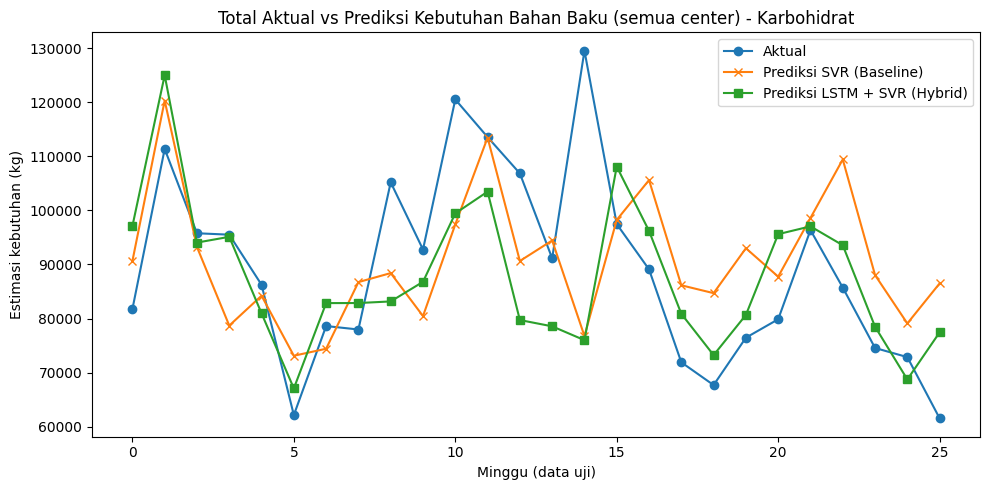

Grafik disimpan: /content/drive/MyDrive/business prediction/results/perbandingan_Karbohidrat.png

KELOMPOK BAHAN BAKU: Sayuran
  - Sayuran: 77 center dipakai, 0 center dilewati (histori < 17 minggu) -> total 10192 window training
Data latih: 8190 sampel (dari 77 center) | Data uji: 2002 sampel (dari 77 center)

[1] Melatih model BASELINE (SVR, window multivariat diratakan, dengan grid search)...
    Best baseline SVR params: {'C': 1, 'epsilon': 0.01, 'gamma': 'scale'}
    RMSE: 59.2264 kg | MAPE: 24.35%  (level: per-center per-minggu)

[2] Melatih model HYBRID (LSTM baca window multivariat sbg deret waktu -> SVR)...
    Mencoba beberapa konfigurasi arsitektur LSTM...
      {'n_lstm_units': 16, 'dense_units': 8, 'learning_rate': 0.001} -> val_loss=0.00485
      {'n_lstm_units': 32, 'dense_units': 16, 'learning_rate': 0.001} -> val_loss=0.00416
      {'n_lstm_units': 48, 'dense_units': 24, 'learning_rate': 0.0005} -> val_loss=0.00460
    Konfigurasi LSTM terbaik: {'n_lstm_units': 32, 'de

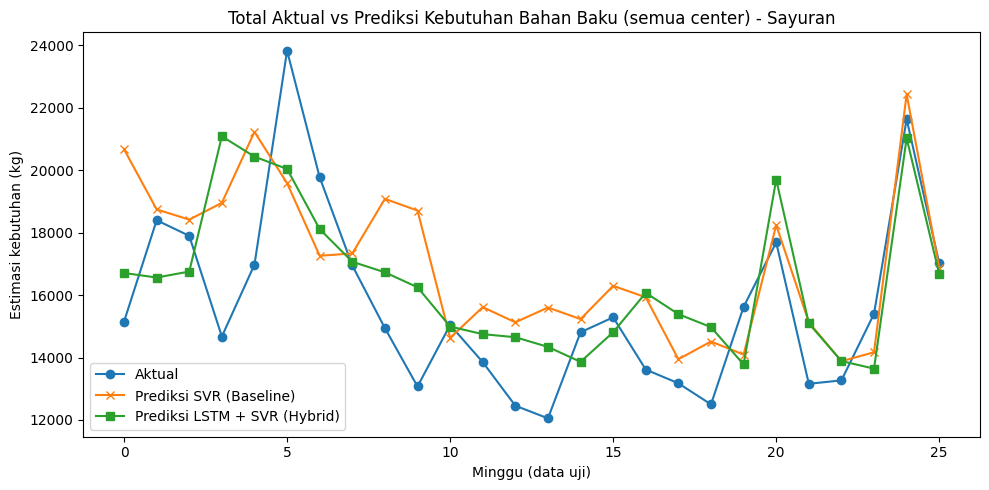

Grafik disimpan: /content/drive/MyDrive/business prediction/results/perbandingan_Sayuran.png

KELOMPOK BAHAN BAKU: Protein
  - Protein: 77 center dipakai, 0 center dilewati (histori < 17 minggu) -> total 9903 window training
Data latih: 7971 sampel (dari 77 center) | Data uji: 1932 sampel (dari 76 center)

[1] Melatih model BASELINE (SVR, window multivariat diratakan, dengan grid search)...
    Best baseline SVR params: {'C': 1, 'epsilon': 0.05, 'gamma': 'scale'}
    RMSE: 44.9134 kg | MAPE: 38.61%  (level: per-center per-minggu)

[2] Melatih model HYBRID (LSTM baca window multivariat sbg deret waktu -> SVR)...
    Mencoba beberapa konfigurasi arsitektur LSTM...
      {'n_lstm_units': 16, 'dense_units': 8, 'learning_rate': 0.001} -> val_loss=0.00955
      {'n_lstm_units': 32, 'dense_units': 16, 'learning_rate': 0.001} -> val_loss=0.00989
      {'n_lstm_units': 48, 'dense_units': 24, 'learning_rate': 0.0005} -> val_loss=0.00931
    Konfigurasi LSTM terbaik: {'n_lstm_units': 48, 'dense_u

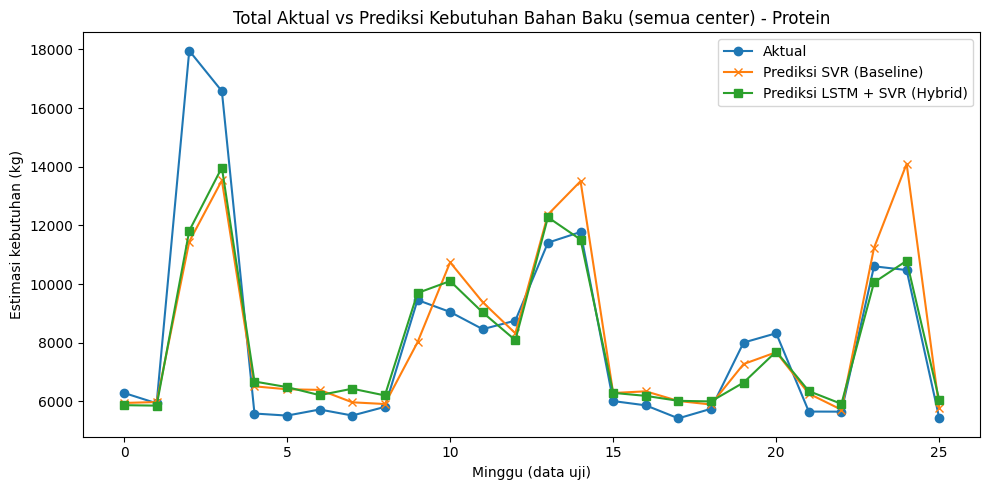

Grafik disimpan: /content/drive/MyDrive/business prediction/results/perbandingan_Protein.png


In [76]:
summary_rows = []

for group in FOOD_GROUPS:
    if group not in df["food_group"].unique():
        print(f"[PERINGATAN] Kelompok '{group}' tidak ditemukan di data, dilewati.")
        continue

    print("\n" + "=" * 70)
    print(f"KELOMPOK BAHAN BAKU: {group}")
    print("=" * 70)

    X, y, center_ids, week_idx, scales, extra = build_center_level_windows(df, group)

    (X_train, X_test, y_train_rel, y_test_rel,
     center_train, center_test, week_train, week_test,
     scale_train, scale_test, extra_train, extra_test) = split_by_global_week_cutoff(
        X, y, center_ids, week_idx, scales, extra
    )

    print(f"Data latih: {len(X_train)} sampel (dari {len(np.unique(center_train))} center) | "
          f"Data uji: {len(X_test)} sampel (dari {len(np.unique(center_test))} center)")

    y_test_kg = np.expm1(y_test_rel) * scale_test

    print("\n[1] Melatih model BASELINE (SVR, window multivariat diratakan, dengan grid search)...")
    baseline_model, base_x_scaler, base_y_scaler = train_baseline_svr(X_train, extra_train, y_train_rel)
    pred_baseline_kg = predict_baseline(baseline_model, base_x_scaler, base_y_scaler, X_test, extra_test, scale_test)
    rmse_base, mape_base = evaluate(y_test_kg, pred_baseline_kg)
    print(f"    RMSE: {rmse_base:.4f} kg | MAPE: {mape_base:.2f}%  (level: per-center per-minggu)")

    print("\n[2] Melatih model HYBRID (LSTM baca window multivariat sbg deret waktu -> SVR)...")
    svr_hybrid, feature_extractor, x_scaler, y_scaler, feat_scaler = train_hybrid_lstm_svr(
        X_train, extra_train, y_train_rel, WINDOW_SIZE
    )
    pred_hybrid_kg = predict_hybrid(
        svr_hybrid, feature_extractor, x_scaler, y_scaler, feat_scaler, X_test, extra_test, WINDOW_SIZE, scale_test
    )
    rmse_hybrid, mape_hybrid = evaluate(y_test_kg, pred_hybrid_kg)
    print(f"    RMSE: {rmse_hybrid:.4f} kg | MAPE: {mape_hybrid:.2f}%  (level: per-center per-minggu)")

    plot_df = pd.DataFrame({
        "week": week_test,
        "actual": y_test_kg,
        "pred_baseline": pred_baseline_kg,
        "pred_hybrid": pred_hybrid_kg,
    }).groupby("week").sum().sort_index()

    plot_path = os.path.join(RESULT_DIR, f"perbandingan_{group}.png")
    plot_comparison(
        plot_df["actual"].values, plot_df["pred_baseline"].values, plot_df["pred_hybrid"].values,
        group, plot_path,
    )
    print(f"Grafik disimpan: {plot_path}")

    summary_rows.append({
        "Kelompok": group,
        "N_Center_Dipakai": len(np.unique(center_ids)),
        "N_Sampel_Train": len(X_train),
        "N_Sampel_Test": len(X_test),
        "RMSE_Baseline_SVR": rmse_base,
        "MAPE_Baseline_SVR(%)": mape_base,
        "RMSE_Hybrid_LSTM_SVR": rmse_hybrid,
        "MAPE_Hybrid_LSTM_SVR(%)": mape_hybrid,
        "Peningkatan_RMSE(%)": (rmse_base - rmse_hybrid) / rmse_base * 100 if rmse_base else np.nan,
    })

In [77]:
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULT_DIR, "ringkasan_evaluasi.csv"), index=False)

print("RINGKASAN HASIL EVALUASI SEMUA KELOMPOK BAHAN BAKU")
summary_df

RINGKASAN HASIL EVALUASI SEMUA KELOMPOK BAHAN BAKU


,Kelompok,N_Center_Dipakai,N_Sampel_Train,N_Sampel_Test,RMSE_Baseline_SVR,MAPE_Baseline_SVR(%),RMSE_Hybrid_LSTM_SVR,MAPE_Hybrid_LSTM_SVR(%),Peningkatan_RMSE(%)
0,Karbohidrat,77,8214,2002,316.175647,19.209029,301.633677,17.133169,4.599333
1,Sayuran,77,8190,2002,59.226445,24.348927,52.965994,21.765706,10.570365
2,Protein,77,7971,1932,44.913416,38.606479,40.393853,35.871042,10.062837
